# 빈도수 기반 텍스트 분석 : 다음 영화 리뷰

1. 데이터 준비 : 로딩, 필요한 데이터 추출
2. 데이터 전처리 : 분석 대상 단어 집합
3. 데이터 분석 : 빈도수
4. 시각화 : 수평 막대 그래프, 워드클라우드

### 1. 데이터 준비

In [1]:
import pandas as pd
datafile = './data/daum_movie_review.csv'
data_df = pd.read_csv(datafile)
data_df.head()

,review,rating,date,title
0,돈 들인건 티가 나지만 보는 내내 하품만,1,2018.10.29,인피니티 워
1,몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.,10,2018.10.26,인피니티 워
2,이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 ...,8,2018.10.24,인피니티 워
3,이 정도면 볼만하다고 할 수 있음!,8,2018.10.22,인피니티 워
4,재미있다,10,2018.10.20,인피니티 워


In [2]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14725 entries, 0 to 14724
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  14725 non-null  object
 1   rating  14725 non-null  int64 
 2   date    14725 non-null  object
 3   title   14725 non-null  object
dtypes: int64(1), object(3)
memory usage: 460.3+ KB


In [3]:
reviews = list(data_df.review)
len(reviews), reviews[:5]

(14725,
 ['돈 들인건 티가 나지만 보는 내내 하품만',
  '몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.',
  '이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 모은 것까지는 좋았으나 이걸 모두 한 그릇에 섞어버린 듯한 느낌... 그래도 다음 작품을 기대하게 만든다...',
  '이 정도면 볼만하다고 할 수 있음!',
  '재미있다'])

### 2. 데이터 전처리

In [ ]:
# 명사 추출
from konlpy.tag import Okt
t = Okt()

all_reviews = " ".join(reviews)

nouns = t.nouns(all_reviews)

print(f'토큰 수 : {len(nouns):,}개')
print(nouns[:10])

토큰 수 : 126,063개
['돈', '티', '나', '내내', '하품', '몰입', '생각', '내', '전투', '참여']


In [5]:
# 명사, 동사, 형용사
my_tags = ['Noun', 'Verb', 'Adjective']
tokens = [word for word, tag in t.pos(all_reviews) if tag in my_tags]

print(f'토큰 수 : {len(tokens):,}개')

tokens[:10]

토큰 수 : 194,792개


['돈', '들인건', '티', '나', '보는', '내내', '하품', '몰입', '할수밖에', '없다']

In [6]:
from collections import Counter

# 빈도수 계산
count = Counter(tokens)

# 상위 20개 키워드 추출
top_20 = count.most_common(20)
print(top_20)

[('영화', 6691), ('연기', 1293), ('감동', 1223), ('생각', 1027), ('정말', 948), ('것', 927), ('이', 851), ('배우', 847), ('사람', 819), ('스토리', 815), ('더', 791), ('진짜', 781), ('잘', 776), ('하는', 770), ('눈물', 737), ('보고', 709), ('점', 692), ('최고', 682), ('좀', 671), ('재미', 641)]


In [14]:
from konlpy.tag import Okt
from collections import Counter

t = Okt()

# 1. 태그 및 불용어 정의
my_tags = ['Noun', 'Verb', 'Adjective']
# 상위 빈도 단어 중 무의미한 것들을 추가해 주세요.
my_stopwords = ['영화', '이', '것', '하는', '정말', '진짜', '보고', '점', '좀', '그', '수', '할', '있는', '때', '보는', '입니다', '그냥', '정도', '봤는데']

# 2. 토큰 추출 및 전처리 (불용어 제거 + 두 글자 이상만)
# stem=True를 넣으면 '봤는데' -> '보다'처럼 원형으로 바뀌어 분석이 더 정확해집니다.
tokens = [word for word, tag in t.pos(all_reviews) 
          if tag in my_tags and len(word) > 1 and word not in my_stopwords]

print(f'전처리 후 토큰 수 : {len(tokens):,}개')

# 3. 빈도수 계산
counter = Counter(tokens)
print(counter.most_common(20))

전처리 후 토큰 수 : 149,269개
[('연기', 1293), ('감동', 1223), ('생각', 1027), ('배우', 847), ('사람', 819), ('스토리', 815), ('눈물', 737), ('최고', 682), ('재미', 641), ('마지막', 612), ('시간', 596), ('마동석', 556), ('광주', 530), ('윤계상', 517), ('기대', 516), ('내용', 494), ('장면', 438), ('원작', 422), ('평점', 407), ('느낌', 400)]


In [15]:
# 데이터 준비 : 빈도수 상위 20개의 단어만 추출
# x 데이터 : word, y 데이터 : count
x = [word for word, count in counter.most_common(20)]
y = [count for word, count in counter.most_common(20)]
print(x[:10])
print(y[:10])

['연기', '감동', '생각', '배우', '사람', '스토리', '눈물', '최고', '재미', '마지막']
[1293, 1223, 1027, 847, 819, 815, 737, 682, 641, 612]


In [9]:
# matplotlib 한글 폰트 설정
from matplotlib import font_manager, rc
font_path = "c:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

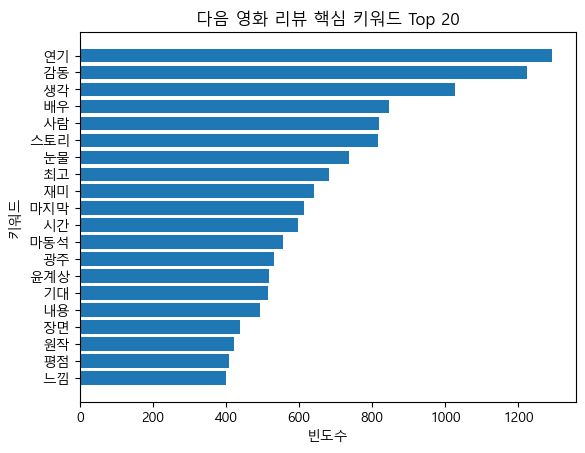

In [ ]:
import matplotlib.pyplot as plt

# 수평 막대그래프
plt.barh(x[::-1], y[::-1])

# 그래프 정보 추가 
plt.title('다음 영화 리뷰 핵심 키워드 Top 20')
plt.xlabel('빈도수')
plt.ylabel('키워드')

# 화면에 출력
plt.show()

# 그래프 저장 : 그래프 생성 후 바로 savefig 사용
# outputfile = datafile.replace('.csv', '_bargraph.png')
# plt.savefig(outputfile)

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 한글 폰트 path 지정
font_path = "c:/Windows/fonts/malgun.ttf"

# WordCloud 객체 생성
const_wc = WordCloud(font_path = font_path, 
                     
                     background_color='ivory'
                     )

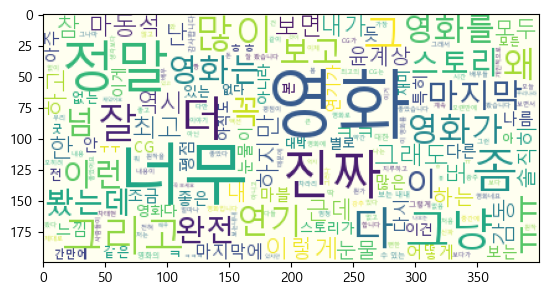

In [19]:
const_wc = const_wc.generate(all_reviews)

plt.imshow(const_wc)
plt.show()

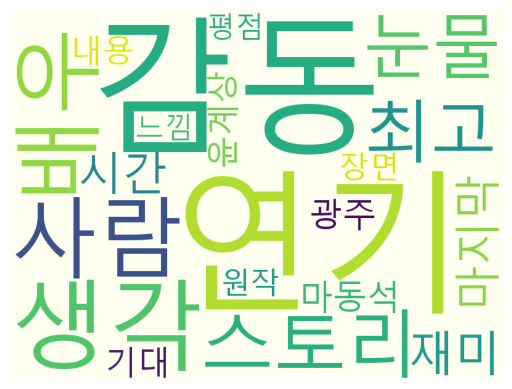

In [21]:
# WordCloud 객체 생성
const_wc = WordCloud(font_path = font_path, 
                     width=800,
                     height=600,
                     max_words=20,
                     background_color='ivory'
                     )

# 빈도 데이터로 워드클라우드 시각화
const_wc = const_wc.generate_from_frequencies(counter)
plt.imshow(const_wc)
plt.axis('off')
plt.show()